<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">

## Project: Fake News Classifier – NLP Challenge (Week 30)

**Goal**: Build a binary classifier that predicts whether a news headline is real (1) or fake (0).  
**Data**: dataset/data.csv (training data) with columns: label, title, text, subject, date.  
**Validation**: dataset/validation_data.csv (labels are 2, to be replaced by 0/1 predictions).  

This notebook follows a structured ML pipeline:
1. Exploratory Data Analysis (EDA)
2. Text Preprocessing & Feature Engineering
3. Model Training & Hyperparameter Tuning
4. Evaluation & Selection
5. Prediction on validation set

</div>

<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
1- Load the necessary libraries
</div>

In [ ]:
# Basic libraries for data manipulation and visualization
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ML & Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

# for handling imbalance
from imblearn.over_sampling import SMOTE

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
2- Load the data
</div>

In [54]:
# Load datasets
data = pd.read_csv('../dataset/data.csv')
validation = pd.read_csv('../dataset/validation_data.csv')

print("Training data shape:", data.shape)
print("Validation data shape:", validation.shape)
display("data.head()", data.head())
display("validation_data.head()",validation.head())

Training data shape: (39942, 5)
Validation data shape: (4956, 5)


'data.head()'

,label,title,text,subject,date
0,1,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,1,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,1,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,1,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


'validation_data.head()'

,label,title,text,subject,date
0,2,UK's May 'receiving regular updates' on London...,LONDON (Reuters) - British Prime Minister Ther...,worldnews,"September 15, 2017"
1,2,UK transport police leading investigation of L...,LONDON (Reuters) - British counter-terrorism p...,worldnews,"September 15, 2017"
2,2,Pacific nations crack down on North Korean shi...,WELLINGTON (Reuters) - South Pacific island na...,worldnews,"September 15, 2017"
3,2,Three suspected al Qaeda militants killed in Y...,"ADEN, Yemen (Reuters) - Three suspected al Qae...",worldnews,"September 15, 2017"
4,2,Chinese academics prod Beijing to consider Nor...,BEIJING (Reuters) - Chinese academics are publ...,worldnews,"September 15, 2017"


<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
3- EDA: Basic Info and Missing Values
</div>

In [55]:
# missing values, non-null counts and data types
print('data.isnull().sum()=', data.isnull().sum())
print("Training data info:")
data.info()

print('validation.isnull().sum()=', validation.isnull().sum())
print("\nValidation data info:")
validation.info()

data.isnull().sum()= label      0
title      0
text       0
subject    0
date       0
dtype: int64
Training data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39942 entries, 0 to 39941
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    39942 non-null  int64 
 1   title    39942 non-null  object
 2   text     39942 non-null  object
 3   subject  39942 non-null  object
 4   date     39942 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.5+ MB
validation.isnull().sum()= label      0
title      0
text       0
subject    0
date       0
dtype: int64

Validation data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4956 entries, 0 to 4955
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    4956 non-null   int64 
 1   title    4956 non-null   object
 2   text     4956 non-null   object
 3   subject  4956 non-null   object
 4   dat

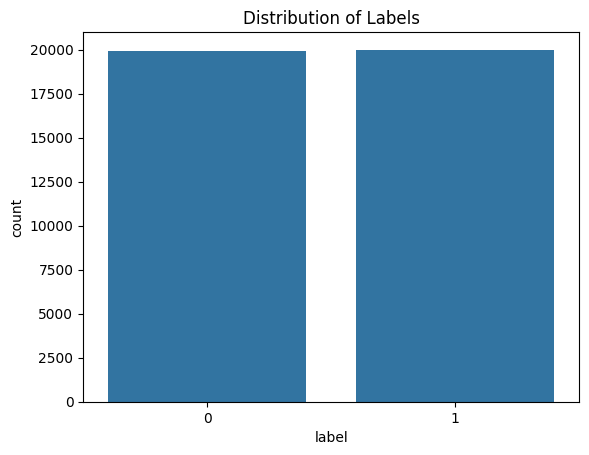

In [56]:
# Label distribution
sns.countplot(x='label', data=data)
plt.title('Distribution of Labels')
plt.show()

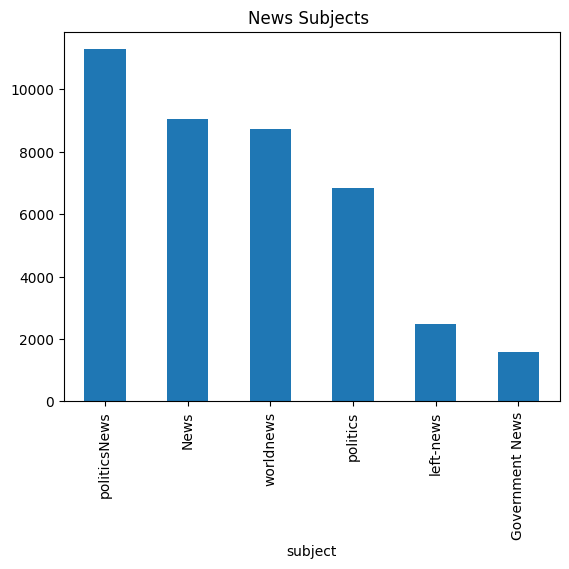

In [57]:
# Subject distribution
data['subject'].value_counts().plot(kind='bar')
plt.title('News Subjects ')
plt.show()

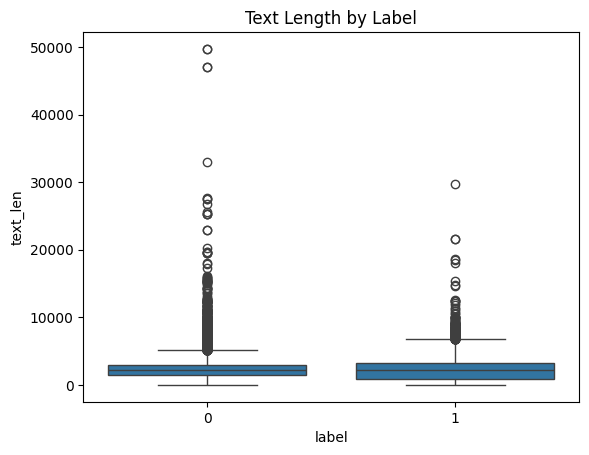

In [58]:
# Length analysis
data['title_len'] = data['title'].apply(len)
data['text_len'] = data['text'].apply(len)
sns.boxplot(x='label', y='text_len', data=data)
plt.title('Text Length by Label')
plt.show()

<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
4- Text Preprocessing Function
</div>

In [59]:
from nltk.tokenize import word_tokenize

# Define a cleaning function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """ define a cleaning function for: lowerecase converting, Remove punctuation and digits, Tokenize, Remove stopwords and lemmatize """
    # Lowercase
    text = text.lower()

    # Remove punctuation and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Apply to title and text (we combine them)
data['clean_title'] = data['title'].apply(clean_text)
data['clean_text'] = data['text'].apply(clean_text)
data['combined'] = data['clean_title'] + ' ' + data['clean_text']

validation['clean_title'] = validation['title'].apply(clean_text)
validation['clean_text'] = validation['text'].apply(clean_text)
validation['combined'] = validation['clean_title'] + ' ' + validation['clean_text']

<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
5- Train/Test Split
</div>

In [61]:
# Features and target
X = data['combined']
y = data['label']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 31953, Test size: 7989


<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
6- Build Pipeline & Model Selection
</div>

In [62]:
# Define TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english',
    sublinear_tf=True
)

# Define models
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'LinearSVC': LinearSVC(random_state=42, max_iter=2000),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Store results
results = {}

for name, model in models.items():
    pipeline = Pipeline([
        ('tfidf', tfidf),
        ('clf', model)
    ])
    # Cross-validation
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy')
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    
    results[name] = {
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'test_acc': test_acc
    }
    print(f"{name}: CV Acc = {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f}), Test Acc = {test_acc:.4f}")

# Select best model (based on CV)
best_name = max(results, key=lambda k: results[k]['cv_mean'])
print(f"\nBest model: {best_name}")

LogisticRegression: CV Acc = 0.9921 (+/- 0.0007), Test Acc = 0.9910
LinearSVC: CV Acc = 0.9969 (+/- 0.0003), Test Acc = 0.9970
RandomForest: CV Acc = 0.9968 (+/- 0.0004), Test Acc = 0.9981

Best model: LinearSVC


<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
7- Hyperparameter Tuning
</div>

In [63]:
# For demonstration, we tune LogisticRegression 
param_grid = {
    'tfidf__max_features': [3000, 5000, 7000],
    'tfidf__ngram_range': [(1,1), (1,2)],
    'clf__C': [0.1, 1, 10]
}

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', sublinear_tf=True)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV score:", grid.best_score_)

best_pipeline = grid.best_estimator_
y_pred = best_pipeline.predict(X_test)
print("Test accuracy after tuning:", accuracy_score(y_test, y_pred))

Best parameters: {'clf__C': 10, 'tfidf__max_features': 5000, 'tfidf__ngram_range': (1, 2)}
Best CV score: 0.9958063483738012
Test accuracy after tuning: 0.9951182876455126


<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
8- Final Evaluation on Test Set
</div>

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      3989
           1       0.99      1.00      1.00      4000

    accuracy                           1.00      7989
   macro avg       1.00      1.00      1.00      7989
weighted avg       1.00      1.00      1.00      7989



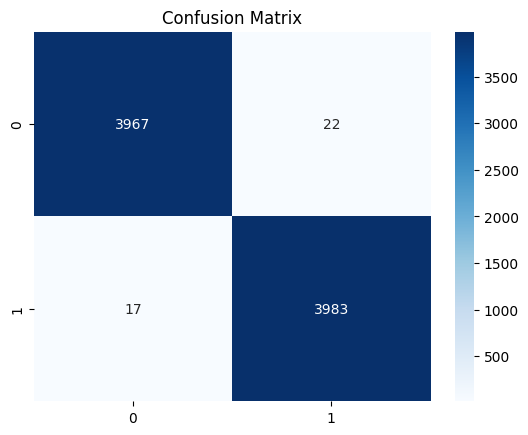

ROC-AUC: 0.9998


In [ ]:

y_pred = best_pipeline.predict(X_test)
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# ROC-AUC 
if hasattr(best_pipeline.named_steps['clf'], 'predict_proba'):
    probs = best_pipeline.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, probs)
    print(f"ROC-AUC: {auc:.4f}")

<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
9- Predict on Validation Data
</div>

In [ ]:
# The validation file has label=2 as placeholder – I overwrite it
validation_pred = best_pipeline.predict(validation['combined'])
validation['label'] = validation_pred

# Keep only original columns (label, title, text, subject, date)
output = validation[['label', 'title', 'text', 'subject', 'date']]
output.to_csv('../dataset/predictions.csv', index=False)
print("Predictions saved to ../dataset/predictions.csv")

Predictions saved to ../dataset/predictions.csv


<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
10- Final Accuracy Estimation
</div>

In [67]:
# To estimate generalization performance using the cross-validation score on the full training set.
# After tuning, the mean CV score as our estimate is used.
estimated_accuracy = grid.best_score_ if 'grid' in locals() else results[best_name]['cv_mean']
print(f"Estimated accuracy on unseen data: {estimated_accuracy:.4f}")

Estimated accuracy on unseen data: 0.9958


<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
6- TF‑IDF Vectorization
</div>

In [23]:
# Initialize TF-IDF with limits (max_features, min_df, etc.)
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2, max_df=0.8)

# Fit on train, transform train and test
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print("TF-IDF shape:", X_train_tfidf.shape)

TF-IDF shape: (31953, 5000)


<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
7- Model Training and Baseline
</div>

In [24]:
# Train a simple Logistic Regression as baseline
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)

print("Baseline Logistic Regression Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("F1-score:", f1_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Baseline Logistic Regression Performance:
Accuracy: 0.9871072724996871
F1-score: 0.9871619095101583
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      3989
           1       0.98      0.99      0.99      4000

    accuracy                           0.99      7989
   macro avg       0.99      0.99      0.99      7989
weighted avg       0.99      0.99      0.99      7989



<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
8- Hyperparameter Tuning 
</div>

In [25]:
# Define parameter grid for Logistic Regression
param_grid = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}
grid = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000),
                    param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train_tfidf, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

# Evaluate on test set
best_lr = grid.best_estimator_
y_pred_best = best_lr.predict(X_test_tfidf)
print("Test F1:", f1_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Best parameters: {'C': 10, 'solver': 'liblinear'}
Best CV F1: 0.993475191051583
Test F1: 0.9927518120469883
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3989
           1       0.99      0.99      0.99      4000

    accuracy                           0.99      7989
   macro avg       0.99      0.99      0.99      7989
weighted avg       0.99      0.99      0.99      7989



<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
9- Try Another Model: LinearSVC
</div>

In [26]:
# LinearSVC often works well for text
svc = LinearSVC(random_state=42, max_iter=2000)
svc.fit(X_train_tfidf, y_train)
y_pred_svc = svc.predict(X_test_tfidf)
print("LinearSVC Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_svc))
print("F1:", f1_score(y_test, y_pred_svc))

LinearSVC Performance:
Accuracy: 0.9946175991988985
F1: 0.9946256717910261


<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
10- Confusion Matrix and Insights
</div>

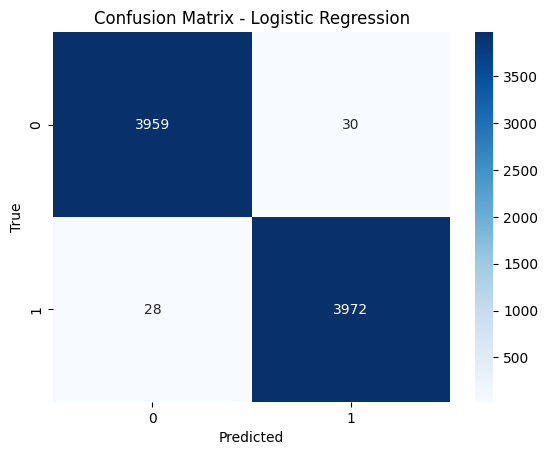

In [27]:
# Plot confusion matrix for best model
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
11- Feature Importance
</div>

In [28]:
# For Logistic Regression, coefficients indicate feature importance
feature_names = tfidf.get_feature_names_out()
coefs = best_lr.coef_[0]
top_n = 20
# Top positive (real) and negative (fake)
top_positive = np.argsort(coefs)[-top_n:]
top_negative = np.argsort(coefs)[:top_n]

print("Top real-indicative words:", [feature_names[i] for i in top_positive])
print("Top fake-indicative words:", [feature_names[i] for i in top_negative])

Top real-indicative words: ['edt', 'he', 'said statement', 'thursday', 'friday', 'president barack', 'dont', 'york reuters', 'nov', 'im', 'factbox', 'tuesday', 'wednesday', 'washington', 'thats', 'reuters president', 'president donald', 'washington reuters', 'said', 'reuters']
Top fake-indicative words: ['via', 'video', 'image', 'breaking', 'president trump', 'gop', 'hillary', 'image via', 'obama', 'read', 'mr', 'saidthe', 'rep', 'even', 'sen', 'watch', 'gov', 'like', 'american', 'know']


<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
12- Predict on Validation Set
</div>

In [29]:
# Preprocess validation full_text 
X_val = validation['clean_text']
X_val_tfidf = tfidf.transform(X_val)
val_pred = best_lr.predict(X_val_tfidf)

# Create submission file (replace label 2 with predictions)
validation_submission = validation.copy()
validation_submission['label'] = val_pred

# Keep only original columns (label, title, text, subject, date) in same order
validation_submission = validation_submission[['label', 'title', 'text', 'subject', 'date']]
validation_submission.to_csv('../dataset/predictions.csv', index=False)
print("Predictions saved to ../dataset/predictions.csv")

Predictions saved to ../dataset/predictions.csv


<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
13- Final Accuracy Estimation
</div>

In [30]:
# Estimate expected performance on unseen data
# Use cross-validation on full training set 
cv_scores = cross_val_score(best_lr, X_train_tfidf, y_train, cv=5, scoring='f1')
print("Cross-validation F1 scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())


Cross-validation F1 scores: [0.992983   0.9937578  0.99375195 0.99343955 0.99344365]
Mean CV F1: 0.993475191051583
Standard deviation: 0.00028318912890112875


<div style="background-color: lightblue; color: black; padding: 10px; border-radius: 5px;">
14- Confusion Matrix and Insights
</div>